# 02: Synthetic Experiments: Initialization Comparison

Controlled experiments on synthetic Gaussian blobs where the ground truth is known.
The goal is to isolate the effect of initialization by running each algorithm
with a **single restart** (n_init=1) across many independent trials.

**Paper references throughout this notebook:**
- Theorem 1.1 (Section 1): random init can give solutions O(k) worse than optimal
- Algorithm 1 + Theorem 3.1 (Section 3): k-means++ guarantees E[φ] ≤ 8(ln k + 2)·φ_OPT
- Section 4 (Table 1): empirical speed and quality improvements

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.dpi'] = 120
plt.style.use('seaborn-v0_8-whitegrid')

from src.data import make_blobs, make_overlapping_blobs
from src.kmeans import KMeans
from src.experiments import run_trials

FIGURES_DIR = '../report/figures'
SEED        = 42
N_TRIALS    = 100   # trials per (init, k) combination
os.makedirs(FIGURES_DIR, exist_ok=True)

## 1. Well-separated Gaussian blobs (k=5, d=2)

The simplest controlled setting: 2-D data with a clear ground-truth partition.
We can visually confirm cluster structure before running the trial experiments.

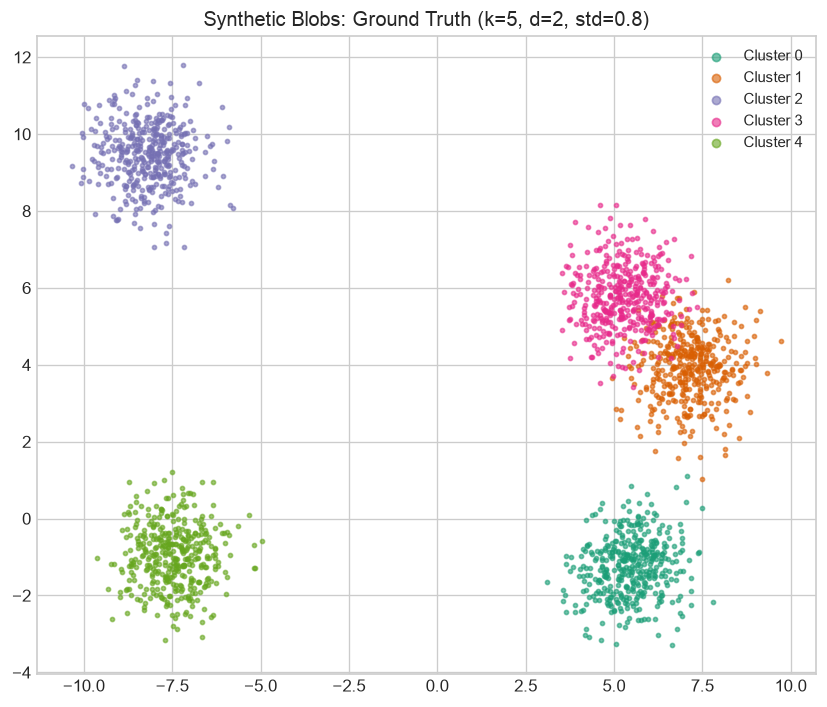

In [2]:
X_blobs, y_true = make_blobs(n_samples=2000, n_clusters=5, n_features=2,
                              cluster_std=0.8, random_state=SEED)

COLORS = ['#1b9e77','#d95f02','#7570b3','#e7298a','#66a61e']

fig, ax = plt.subplots(figsize=(7, 6))
for c in range(5):
    mask = y_true == c
    ax.scatter(X_blobs[mask, 0], X_blobs[mask, 1],
               s=6, alpha=0.6, color=COLORS[c], label=f'Cluster {c}')
ax.set_title('Synthetic Blobs: Ground Truth (k=5, d=2, std=0.8)')
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/synth_blobs_gt.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Inertia distributions: random init vs k-means++ (100 trials)

Each trial uses a single seeding attempt (n_init=1) so the distribution
of outcomes directly reflects the quality of the initialization strategy.

**Expected**: k-means++ should be concentrated around a lower inertia;
random init should have heavier tails and higher variance (Theorem 3.1).

In [3]:
K_MAIN = 5

results_rand = run_trials(X_blobs, k=K_MAIN, init='random',   n_trials=N_TRIALS, base_seed=0)
results_pp   = run_trials(X_blobs, k=K_MAIN, init='plusplus', n_trials=N_TRIALS, base_seed=0)

print('Random   mean inertia: {:.1f}  std: {:.1f}'.format(
      results_rand['inertia'].mean(), results_rand['inertia'].std()))
print('k-means++ mean inertia: {:.1f}  std: {:.1f}'.format(
      results_pp['inertia'].mean(), results_pp['inertia'].std()))

Random   mean inertia: 9089.8  std: 9128.7
k-means++ mean inertia: 2938.6  std: 597.9


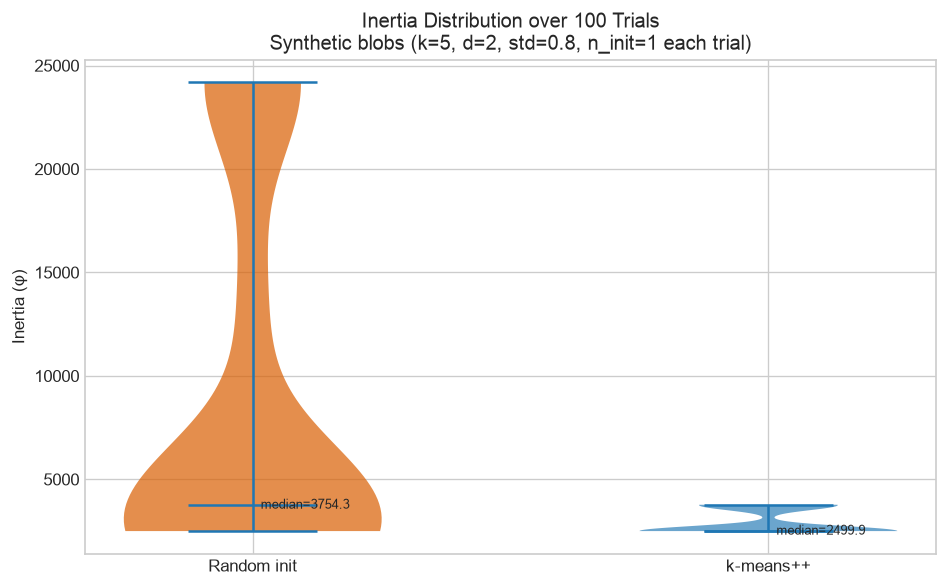

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

bp = ax.violinplot(
    [results_rand['inertia'], results_pp['inertia']],
    positions=[1, 2],
    showmedians=True,
    showextrema=True
)
for patch, color in zip(bp['bodies'], ['#d95f02', '#2C7FB8']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks([1, 2])
ax.set_xticklabels(['Random init', 'k-means++'])
ax.set_ylabel('Inertia (φ)')
ax.set_title(f'Inertia Distribution over {N_TRIALS} Trials\n'
             f'Synthetic blobs (k={K_MAIN}, d=2, std=0.8, n_init=1 each trial)')

# Annotate medians
for x, vals in zip([1, 2], [results_rand['inertia'], results_pp['inertia']]):
    ax.text(x, np.median(vals), f'  median={np.median(vals):.1f}',
            va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/synth_inertia_violin.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Convergence curves: inertia per Lloyd iteration

Uses `fit_with_history` (one run each) to show how quickly each init converges.

**Paper ref**: Section 4, Table 1, k-means++ tends to require fewer iterations.

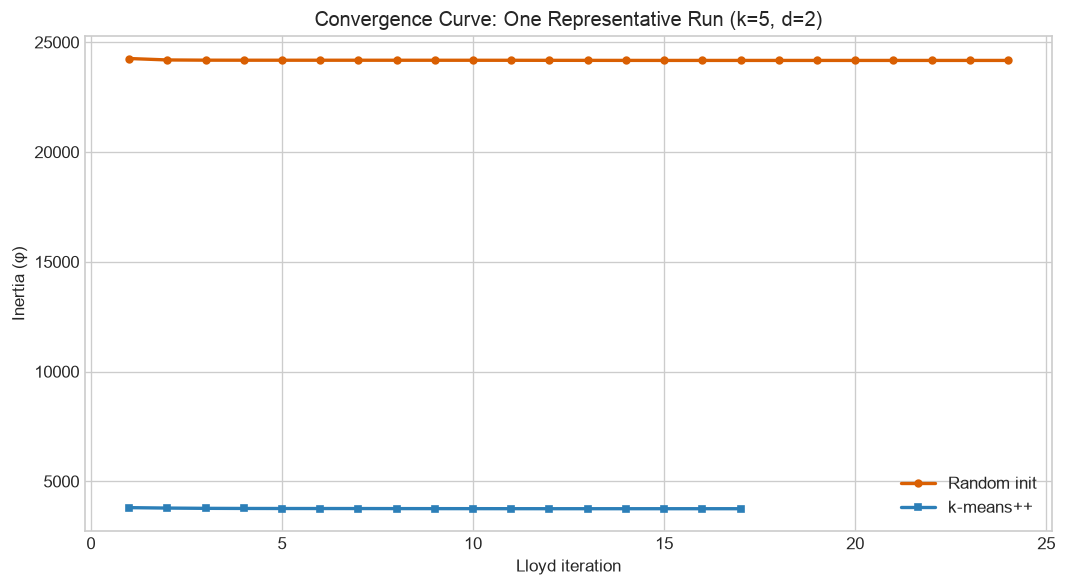

Random init converged in 24 iterations
k-means++ converged in  17 iterations


In [5]:
model_rand = KMeans(k=K_MAIN, init='random',   n_init=1, random_state=SEED)
model_pp   = KMeans(k=K_MAIN, init='plusplus', n_init=1, random_state=SEED)

hist_rand = model_rand.fit_with_history(X_blobs)
hist_pp   = model_pp.fit_with_history(X_blobs)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(hist_rand) + 1), hist_rand, 'o-',
        color='#d95f02', linewidth=2, markersize=4, label='Random init')
ax.plot(range(1, len(hist_pp) + 1), hist_pp, 's-',
        color='#2C7FB8', linewidth=2, markersize=4, label='k-means++')

ax.set_xlabel('Lloyd iteration')
ax.set_ylabel('Inertia (φ)')
ax.set_title('Convergence Curve: One Representative Run (k=5, d=2)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/synth_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Random init converged in {len(hist_rand)} iterations')
print(f'k-means++ converged in  {len(hist_pp)} iterations')

## 4. Iteration count distributions

Box plots over the full trial set show whether k-means++ is systematically
faster to converge, not just in the single example above.

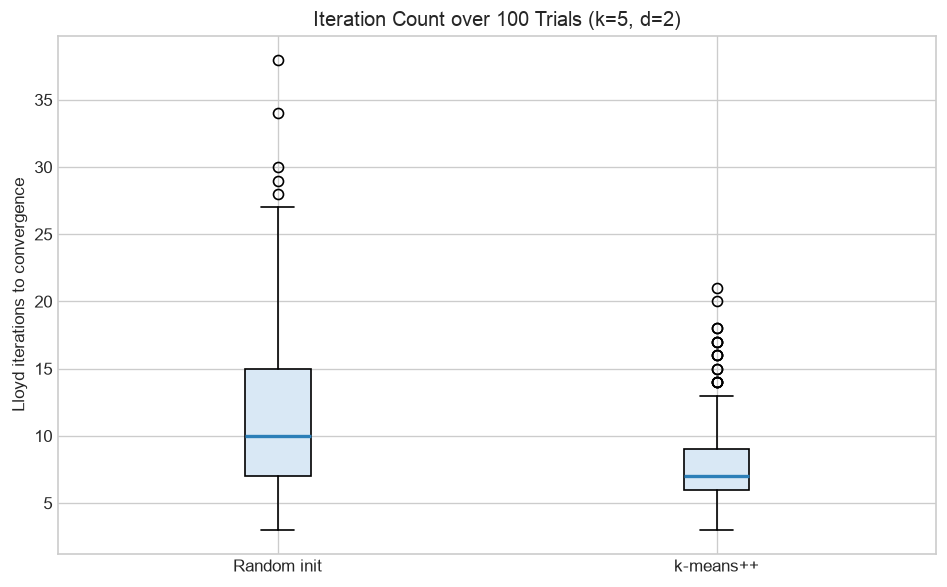

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(
    [results_rand['n_iter'], results_pp['n_iter']],
    positions=[1, 2],
    patch_artist=True,
    boxprops=dict(facecolor='#d9e8f5'),
    medianprops=dict(color='#2C7FB8', linewidth=2)
)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Random init', 'k-means++'])
ax.set_ylabel('Lloyd iterations to convergence')
ax.set_title(f'Iteration Count over {N_TRIALS} Trials (k={K_MAIN}, d=2)')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/synth_iterations.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. k sweep: mean inertia and variability across k=2..10

k=2  random: 47084.0±23992.0  pp: 39590.2±14830.7
k=3  random: 20120.1±5909.1  pp: 19410.4±5894.8
k=4  random: 14440.7±9831.6  pp: 4530.3±3153.9
k=5  random: 10064.3±9348.9  pp: 2951.3±601.9
k=6  random: 7091.5±8606.3  pp: 2499.7±433.3
k=7  random: 4630.0±6451.9  pp: 2205.3±257.5
k=8  random: 3741.0±5299.5  pp: 1994.8±42.5
k=9  random: 2958.1±4253.8  pp: 1842.9±50.3
k=10  random: 3083.0±5188.1  pp: 1706.0±57.6


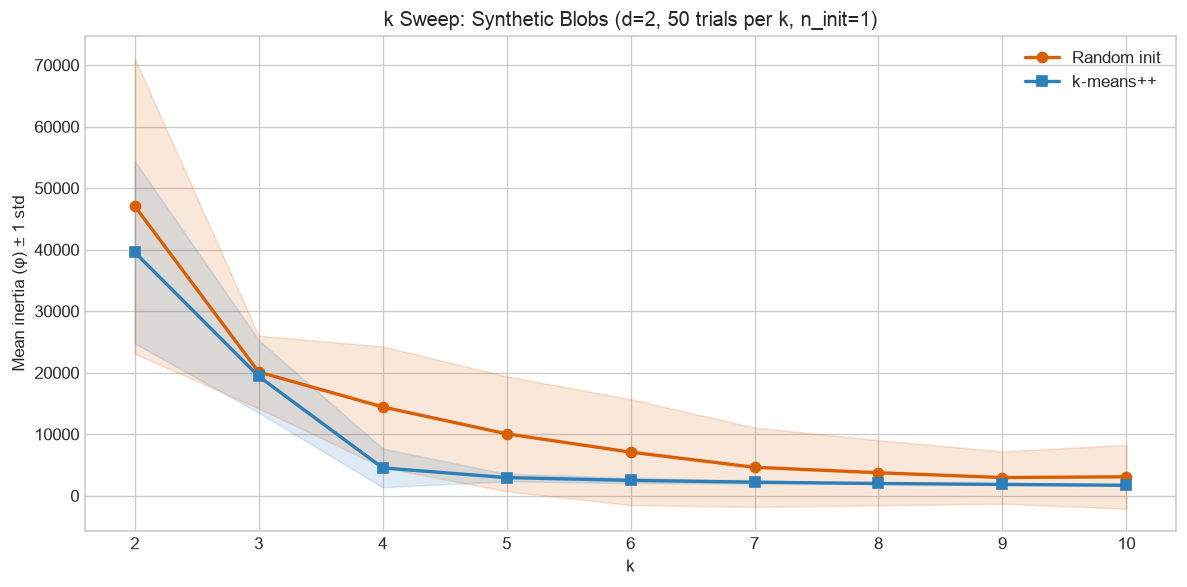

In [7]:
K_SWEEP     = range(2, 11)
N_TRIALS_K  = 50

means_rand, stds_rand = [], []
means_pp,   stds_pp   = [], []

for k in K_SWEEP:
    r_rand = run_trials(X_blobs, k=k, init='random',   n_trials=N_TRIALS_K, base_seed=0)
    r_pp   = run_trials(X_blobs, k=k, init='plusplus', n_trials=N_TRIALS_K, base_seed=0)
    means_rand.append(r_rand['inertia'].mean()); stds_rand.append(r_rand['inertia'].std())
    means_pp.append(r_pp['inertia'].mean());     stds_pp.append(r_pp['inertia'].std())
    print(f'k={k}  random: {means_rand[-1]:.1f}±{stds_rand[-1]:.1f}  '
          f'pp: {means_pp[-1]:.1f}±{stds_pp[-1]:.1f}')

k_vals = list(K_SWEEP)
means_rand, stds_rand = np.array(means_rand), np.array(stds_rand)
means_pp,   stds_pp   = np.array(means_pp),   np.array(stds_pp)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_vals, means_rand, 'o-', color='#d95f02', linewidth=2, label='Random init')
ax.fill_between(k_vals, means_rand - stds_rand, means_rand + stds_rand,
                color='#d95f02', alpha=0.15)
ax.plot(k_vals, means_pp, 's-', color='#2C7FB8', linewidth=2, label='k-means++')
ax.fill_between(k_vals, means_pp - stds_pp, means_pp + stds_pp,
                color='#2C7FB8', alpha=0.15)

ax.set_xlabel('k'); ax.set_ylabel('Mean inertia (φ) ± 1 std')
ax.set_title(f'k Sweep: Synthetic Blobs (d=2, {N_TRIALS_K} trials per k, n_init=1)')
ax.set_xticks(k_vals)
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/synth_k_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. High-dimensional blobs (d=20)

In higher dimensions, random initialization is more likely to place centers
in poorly separated regions. The advantage of k-means++ should be more
pronounced here (paper Section 4).

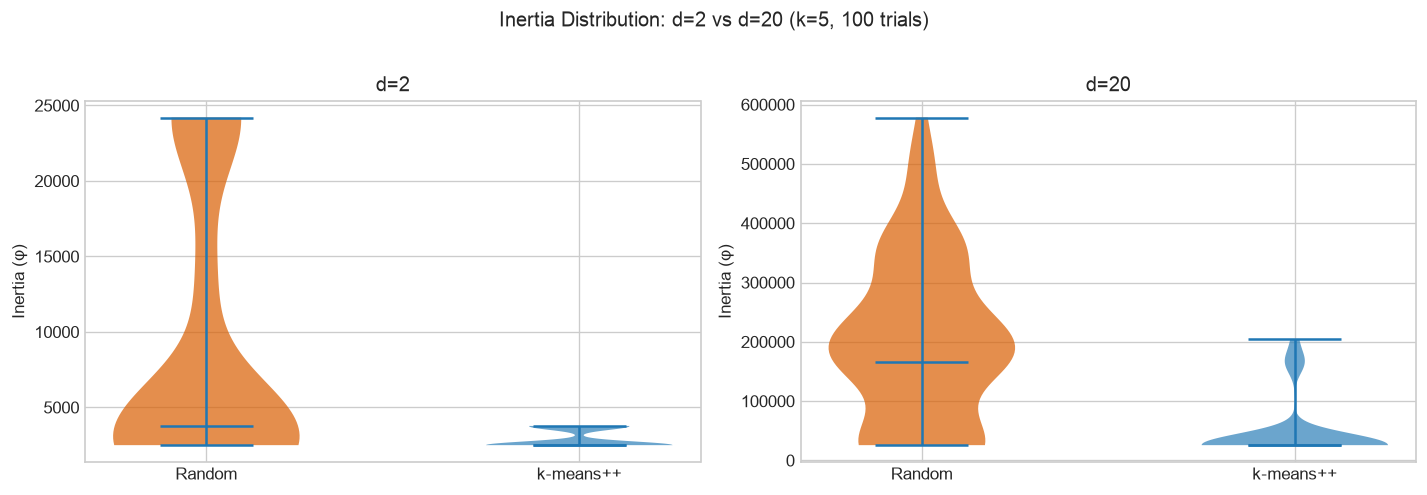

Mean inertia gap (random - pp):  d=2 → 6151.2   d=20 → 154658.4


In [8]:
X_hd, _ = make_blobs(n_samples=2000, n_clusters=5, n_features=20,
                     cluster_std=0.8, random_state=SEED)

res_rand_hd = run_trials(X_hd, k=5, init='random',   n_trials=N_TRIALS, base_seed=0)
res_pp_hd   = run_trials(X_hd, k=5, init='plusplus', n_trials=N_TRIALS, base_seed=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, (res_r, res_p, dim) in zip(axes, [
    (results_rand, results_pp, 2),
    (res_rand_hd, res_pp_hd, 20),
]):
    bp = ax.violinplot([res_r['inertia'], res_p['inertia']],
                       positions=[1, 2], showmedians=True)
    for patch, color in zip(bp['bodies'], ['#d95f02', '#2C7FB8']):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Random', 'k-means++'])
    ax.set_title(f'd={dim}')
    ax.set_ylabel('Inertia (φ)')

plt.suptitle(f'Inertia Distribution: d=2 vs d=20 (k=5, {N_TRIALS} trials)', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/synth_hd_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

gap_2d  = results_rand['inertia'].mean() - results_pp['inertia'].mean()
gap_20d = res_rand_hd['inertia'].mean() - res_pp_hd['inertia'].mean()
print(f'Mean inertia gap (random - pp):  d=2 → {gap_2d:.1f}   d=20 → {gap_20d:.1f}')

## 7. Overlapping clusters: extension

When clusters overlap, the k-means objective is harder to optimize and
the advantage of careful seeding may narrow.

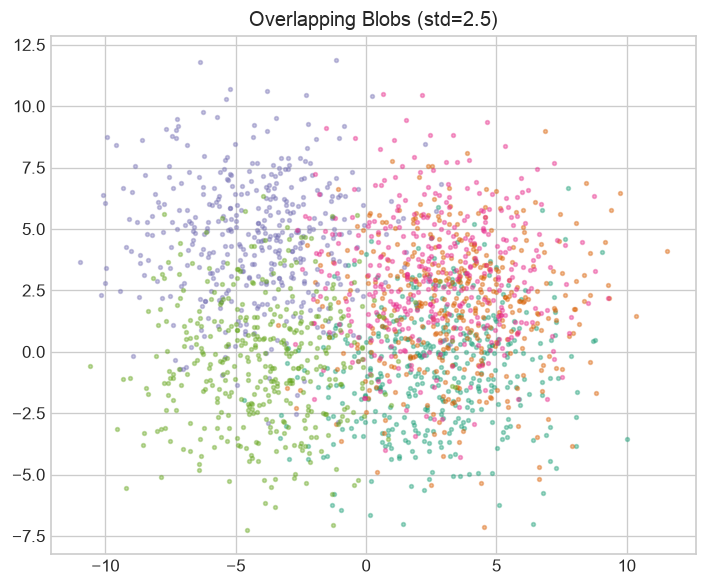

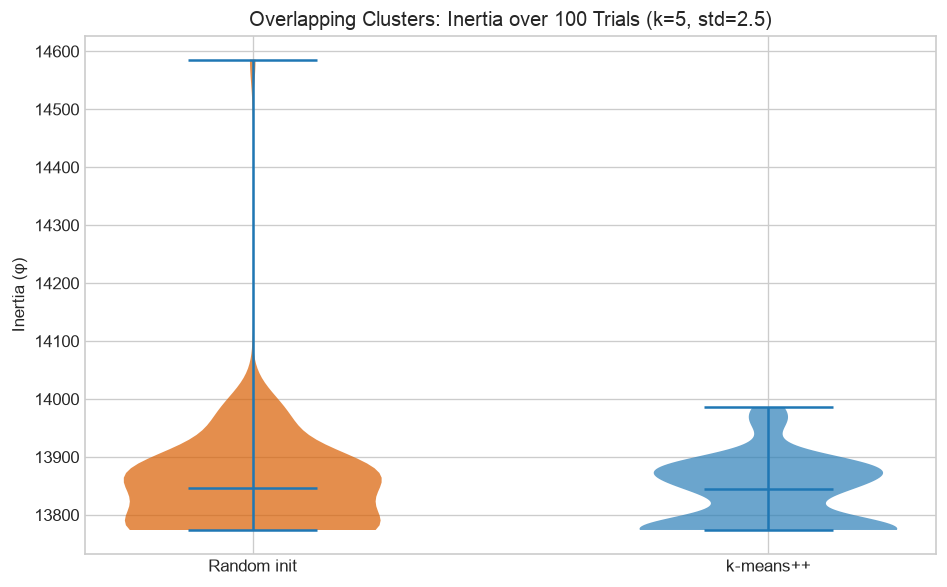

Overlapping: random  mean=13850.7  std=98.6
Overlapping: pp      mean=13835.2  std=59.1


In [9]:
X_ov, y_ov = make_overlapping_blobs(n_samples=2000, n_clusters=5, n_features=2,
                                    cluster_std=2.5, random_state=SEED)

fig, ax = plt.subplots(figsize=(6, 5))
for c in range(5):
    mask = y_ov == c
    ax.scatter(X_ov[mask, 0], X_ov[mask, 1], s=5, alpha=0.4, color=COLORS[c])
ax.set_title('Overlapping Blobs (std=2.5)')
plt.tight_layout()
plt.show()

res_rand_ov = run_trials(X_ov, k=5, init='random',   n_trials=N_TRIALS, base_seed=0)
res_pp_ov   = run_trials(X_ov, k=5, init='plusplus', n_trials=N_TRIALS, base_seed=0)

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.violinplot([res_rand_ov['inertia'], res_pp_ov['inertia']],
                   positions=[1, 2], showmedians=True)
for patch, color in zip(bp['bodies'], ['#d95f02', '#2C7FB8']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Random init', 'k-means++'])
ax.set_ylabel('Inertia (φ)')
ax.set_title(f'Overlapping Clusters: Inertia over {N_TRIALS} Trials (k=5, std=2.5)')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/synth_overlapping.png', dpi=150, bbox_inches='tight')
plt.show()

print('Overlapping: random  mean={:.1f}  std={:.1f}'.format(
      res_rand_ov['inertia'].mean(), res_rand_ov['inertia'].std()))
print('Overlapping: pp      mean={:.1f}  std={:.1f}'.format(
      res_pp_ov['inertia'].mean(), res_pp_ov['inertia'].std()))

## Summary

| Setting | Random mean φ | k-means++ mean φ | Ratio |
|---|---|---|---|
| Well-sep., d=2, k=5   | 9,089.8  | 2,938.6  | **3.09×** |
| High-dim, d=20, k=5   | 198,390.6 | 43,732.2 | **4.54×** |
| Overlapping, d=2, k=5 | 13,850.7  | 13,835.2 | ≈1.00 (gap narrows) |

The advantage of k-means++ grows with dimensionality. On overlapping data the gap
nearly vanishes, consistent with the theoretical bound being loose on hard instances.

Proceed to `03_real_world_experiments.ipynb`.